# Pandas (Merging Data Frames)

This Notebook includes the following contents:

* Merging and types of Join.

  - Inner Join.
  - Left Join.
  - Right Join.
  - Outer Join.
  - Merging on single key.
  - Merging on multiple keys.

* Join Function.



# Merging data frames

Merging in pandas is like combining two sets of data based on a common piece of information.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# df 1
data1 = {'ID': [1, 2, 3, 4],
         'Name': ['Dania', 'Nezar', 'Saleem', 'Ahmad']}
df1 = pd.DataFrame(data1)

# df 2
data2 = {'ID': [3, 4, 5, 6],
         'Age': [23, 24, 25, 26]}
df2 = pd.DataFrame(data2)

In [3]:
df1

,ID,Name
0,1,Dania
1,2,Nezar
2,3,Saleem
3,4,Ahmad


In [4]:
df2

,ID,Age
0,3,23
1,4,24
2,5,25
3,6,26


## Inner Join

(Default) An inner join returns only the rows where the keys match in both DataFrames.**

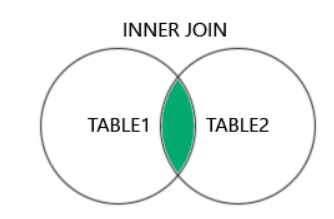

In [5]:
df1

,ID,Name
0,1,Dania
1,2,Nezar
2,3,Saleem
3,4,Ahmad


In [6]:
df2

,ID,Age
0,3,23
1,4,24
2,5,25
3,6,26


In [10]:
 # 3 and 4 are common keys between two tables
inner_merged = pd.merge(df1, df2, on= 'ID', how='inner')
inner_merged

,ID,Name,Age
0,3,Saleem,23
1,4,Ahmad,24


More Example:

In [11]:
students = pd.DataFrame({'student_name': ['Shadi', 'Samer', 'Walaa', 'Nuha'],
                     'age': ['34', '23', '24', '31'],
                     'course': ['AI', 'AI', 'Business', 'CS']})

courses = pd.DataFrame({'course_name': ['AI', 'Business', 'CS', 'BI'],
                          'instructor': ['Mr. Waleed', 'Ms. Samar', 'Mr. Ahmad', 'Ms. Batool']})

In [12]:
students

,student_name,age,course
0,Shadi,34,AI
1,Samer,23,AI
2,Walaa,24,Business
3,Nuha,31,CS


In [13]:
courses

,course_name,instructor
0,AI,Mr. Waleed
1,Business,Ms. Samar
2,CS,Mr. Ahmad
3,BI,Ms. Batool


If the shared columns do not have the same name --> use left_on & right_on

In [17]:
pd.merge(students, courses, how='inner', left_on='course', right_on='course_name')

,student_name,age,course,course_name,instructor
0,Shadi,34,AI,AI,Mr. Waleed
1,Samer,23,AI,AI,Mr. Waleed
2,Walaa,24,Business,Business,Ms. Samar
3,Nuha,31,CS,CS,Mr. Ahmad


## Left Join
Returns all the rows from the left DataFrame (df1), and only matching rows from the right DataFrame (df2).

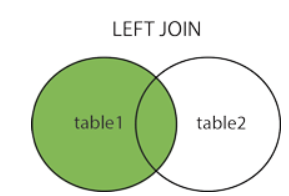

In [18]:
df1

,ID,Name
0,1,Dania
1,2,Nezar
2,3,Saleem
3,4,Ahmad


In [19]:
df2

,ID,Age
0,3,23
1,4,24
2,5,25
3,6,26


In [20]:
# all rows from df1 will be included , if there is no match in df2, NaN will appear in the unmatched columns

left_merged = pd.merge(df1, df2, on='ID', how='left')
left_merged

,ID,Name,Age
0,1,Dania,NaN
1,2,Nezar,NaN
2,3,Saleem,23.0
3,4,Ahmad,24.0


In [21]:
left_merged = pd.merge(df2, df1, on='ID', how='left')
left_merged

,ID,Age,Name
0,3,23,Saleem
1,4,24,Ahmad
2,5,25,NaN
3,6,26,NaN


## Right Join
Returns all the rows from the right DataFrame (df2), and only matching rows from the left DataFrame (df1).

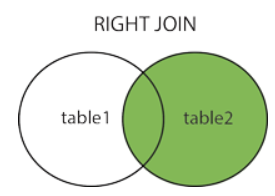

In [22]:
df1

,ID,Name
0,1,Dania
1,2,Nezar
2,3,Saleem
3,4,Ahmad


In [23]:
df2

,ID,Age
0,3,23
1,4,24
2,5,25
3,6,26


In [24]:
# RIGHT JOIN is rarely used because you can achieve the results of a RIGHT JOIN by simply switching the two joined table names
right_merged = pd.merge(df1, df2, on='ID', how='right')
right_merged

,ID,Name,Age
0,3,Saleem,23
1,4,Ahmad,24
2,5,NaN,25
3,6,NaN,26


## Outer Join
Returns all the rows from both DataFrames, and NaN for missing matches.

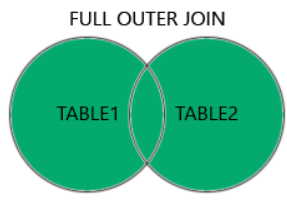

In [25]:
df1

,ID,Name
0,1,Dania
1,2,Nezar
2,3,Saleem
3,4,Ahmad


In [26]:
df2

,ID,Age
0,3,23
1,4,24
2,5,25
3,6,26


In [27]:
# All rows from both df1 and df2 will be included. NaN will fill in for any missing values.

outer_merged = pd.merge(df1, df2, on='ID', how='outer')
outer_merged

,ID,Name,Age
0,1,Dania,NaN
1,2,Nezar,NaN
2,3,Saleem,23.0
3,4,Ahmad,24.0
4,5,NaN,25.0
5,6,NaN,26.0


## Merging on single key

In [28]:
# creating a DataFrame for employees
employees = pd.DataFrame({
    'EmployeeID': [1, 2, 3, 4],
    'Name': ['Karam', 'Yafa', 'Batool', 'MOhammad'],
    'DeptID': [101, 102, 101, 103]
})

# creating another DataFrame for departments
departments = pd.DataFrame({
    'DeptID': [101, 102, 103],
    'DeptName': ['HR', 'IT', 'Finance']
})

In [29]:
employees

,EmployeeID,Name,DeptID
0,1,Karam,101
1,2,Yafa,102
2,3,Batool,101
3,4,MOhammad,103


In [30]:
departments

,DeptID,DeptName
0,101,HR
1,102,IT
2,103,Finance


In [33]:
# merging the DataFrames on 'DeptID'
merged_df = employees.merge(departments, on='DeptID')
merged_df

,EmployeeID,Name,DeptID,DeptName
0,1,Karam,101,HR
1,2,Yafa,102,IT
2,3,Batool,101,HR
3,4,MOhammad,103,Finance


In [34]:
# merging on multiple keys

employee_df = pd.DataFrame({
    'EmployeeID': [1, 2, 3],
    'DepartmentID': [101, 102, 103],
    'EmployeeName': ['Batool', 'Karam', 'Saeed']
})

# salary table
salary_df = pd.DataFrame({
    'EmployeeID': [1, 2, 3],
    'DepartmentID': [101, 102, 104],
    'Salary': [50000, 60000, 55000]
})


In [35]:
employee_df

,EmployeeID,DepartmentID,EmployeeName
0,1,101,Batool
1,2,102,Karam
2,3,103,Saeed


In [36]:
salary_df

,EmployeeID,DepartmentID,Salary
0,1,101,50000
1,2,102,60000
2,3,104,55000


## Merging on multiple keys

In [37]:
# merging on multiple keys: EmployeeID and DepartmentID
merged_df = pd.merge(employee_df, salary_df, on = ['EmployeeID', 'DepartmentID'] , how = 'left')
merged_df

,EmployeeID,DepartmentID,EmployeeName,Salary
0,1,101,Batool,50000.0
1,2,102,Karam,60000.0
2,3,103,Saeed,NaN


In [38]:
merged_df = pd.merge(employee_df, salary_df, on = ['EmployeeID', 'DepartmentID'] , how = 'outer')
merged_df

,EmployeeID,DepartmentID,EmployeeName,Salary
0,1,101,Batool,50000.0
1,2,102,Karam,60000.0
2,3,103,Saeed,NaN
3,3,104,NaN,55000.0


# Join Function

Joining is a convenient method for combining the columns of two potentially differently-indexed DataFrames into a single result DataFrame.

In [39]:
left = pd.DataFrame({'A': ['A0', 'A1', 'A2'],
                     'B': ['B0', 'B1', 'B2']},
                      index=['K0', 'K1', 'K2'])

right = pd.DataFrame({'C': ['C0', 'C2', 'C3'],
                    'D': ['D0', 'D2', 'D3']},
                      index=['K0', 'K2', 'K3'])

In [40]:
left

,A,B
K0,A0,B0
K1,A1,B1
K2,A2,B2


In [41]:
right

,C,D
K0,C0,D0
K2,C2,D2
K3,C3,D3


In [43]:
left.join(right)  # Why the Nans here? What's the default Join? (left join)

,A,B,C,D
K0,A0,B0,C0,D0
K1,A1,B1,NaN,NaN
K2,A2,B2,C2,D2


In [44]:
left.join(right, how='inner')

,A,B,C,D
K0,A0,B0,C0,D0
K2,A2,B2,C2,D2


In [45]:
left.join(right, how='right')

,A,B,C,D
K0,A0,B0,C0,D0
K2,A2,B2,C2,D2
K3,NaN,NaN,C3,D3


In [46]:
left.join(right, how='outer')

,A,B,C,D
K0,A0,B0,C0,D0
K1,A1,B1,NaN,NaN
K2,A2,B2,C2,D2
K3,NaN,NaN,C3,D3


# Task

Using the following DataFrames:
```
import pandas as pd

df_info = pd.DataFrame({
    'Name': ['Ali', 'Lina', 'Sami', 'Rana'],
    'Department': ['HR', 'IT', 'Finance', 'IT']
}, index=[101, 102, 103, 104])  # Employee IDs

df_salary = pd.DataFrame({
    'Salary': [4000, 5500, 7000]
}, index=[101, 102, 103])

```

1. Use multiple joins using the .join() method to combine df_info and df_salary DataFrame using their indexes.

2. For each type of Join describe the resulting DataFrame.


In [47]:
df_info = pd.DataFrame({
    'Name': ['Ali', 'Lina', 'Sami', 'Rana'],
    'Department': ['HR', 'IT', 'Finance', 'IT']
}, index=[101, 102, 103, 104])  # Employee IDs

df_salary = pd.DataFrame({
    'Salary': [4000, 5500, 7000, 6250]
}, index=[101, 102, 103, 105])

In [48]:
df_info

,Name,Department
101,Ali,HR
102,Lina,IT
103,Sami,Finance
104,Rana,IT


In [49]:
df_salary

,Salary
101,4000
102,5500
103,7000
105,6250


In [51]:
df_info.join(df_salary, how='left') # will join based on the index of df_info

,Name,Department,Salary
101,Ali,HR,4000.0
102,Lina,IT,5500.0
103,Sami,Finance,7000.0
104,Rana,IT,NaN


In [ ]:
df_info.join(df_salary, how='right') # will join based on the index of df_salary

,Name,Department,Salary
101,Ali,HR,4000
102,Lina,IT,5500
103,Sami,Finance,7000
105,NaN,NaN,6250


In [53]:
df_info.join(df_salary, how='outer') # will join based on the index of both DataFrames

,Name,Department,Salary
101,Ali,HR,4000.0
102,Lina,IT,5500.0
103,Sami,Finance,7000.0
104,Rana,IT,NaN
105,NaN,NaN,6250.0


In [54]:
df_info.join(df_salary, how='inner') # will join based on the index of both DataFrames, only keeping rows with matching indices 

,Name,Department,Salary
101,Ali,HR,4000
102,Lina,IT,5500
103,Sami,Finance,7000


# Concatenation

Concatenation basically glues together DataFrames. Keep in mind that dimensions should match along the axis you are concatenating on. You can use pd.concat and pass in a list of DataFrames to concatenate together:

In [55]:
df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2', 'A3'],
                    'B': ['B0', 'B1', 'B2', 'B3'],
                    'C': ['C0', 'C1', 'C2', 'C3'],
                    'D': ['D0', 'D1', 'D2', 'D3']},
                    index=[0, 1, 2, 3])

In [56]:
df2 = pd.DataFrame({'E': ['A4', 'A5', 'A6', 'A7'],
                    'B': ['B4', 'B5', 'B6', 'B7'],
                    'C': ['C4', 'C5', 'C6', 'C7'],
                    'D': ['D4', 'D5', 'D6', 'D7'],
                    'F': [0, 0, 0, 0]},
                    index=[0, 1, 2, 3])

In [57]:
df3 = pd.DataFrame({'A': ['A8', 'A9', 'A10', 'A11'],
                    'B': ['B8', 'B9', 'B10', 'B11'],
                    'C': ['C8', 'C9', 'C10', 'C11'],
                    'D': ['D8', 'D9', 'D10', 'D11']},
                    index=[8, 9, 10, 11])

In [58]:
df1

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3


In [59]:
df2

,E,B,C,D,F
0,A4,B4,C4,D4,0
1,A5,B5,C5,D5,0
2,A6,B6,C6,D6,0
3,A7,B7,C7,D7,0


In [60]:
df3

,A,B,C,D
8,A8,B8,C8,D8
9,A9,B9,C9,D9
10,A10,B10,C10,D10
11,A11,B11,C11,D11


In [61]:
pd.concat([df1,df2,df3], axis=0,  ignore_index=True)

,A,B,C,D,E,F
0,A0,B0,C0,D0,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN
2,A2,B2,C2,D2,NaN,NaN
3,A3,B3,C3,D3,NaN,NaN
4,NaN,B4,C4,D4,A4,0.0
5,NaN,B5,C5,D5,A5,0.0
6,NaN,B6,C6,D6,A6,0.0
7,NaN,B7,C7,D7,A7,0.0
8,A8,B8,C8,D8,NaN,NaN
9,A9,B9,C9,D9,NaN,NaN


In [63]:
pd.concat([df1,df2,df3], axis=1) # What happened here? (axis=1 means columns)

,A,B,C,D,E,B,C,D,F,A,B,C,D
0,A0,B0,C0,D0,A4,B4,C4,D4,0.0,NaN,NaN,NaN,NaN
1,A1,B1,C1,D1,A5,B5,C5,D5,0.0,NaN,NaN,NaN,NaN
2,A2,B2,C2,D2,A6,B6,C6,D6,0.0,NaN,NaN,NaN,NaN
3,A3,B3,C3,D3,A7,B7,C7,D7,0.0,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A8,B8,C8,D8
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A9,B9,C9,D9
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A10,B10,C10,D10
11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A11,B11,C11,D11


# Great Job ❤